<a href="https://colab.research.google.com/github/tanmaynolkha/ml_project/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Import libraries
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/content/CarPrice_Assignment.csv")

print(df.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [8]:
df.drop("car_ID", axis=1, inplace=True)

In [9]:
le = LabelEncoder()

categorical_cols = ['CarName','fueltype','aspiration','doornumber',
                    'carbody','drivewheel','enginelocation',
                    'enginetype','cylindernumber','fuelsystem']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

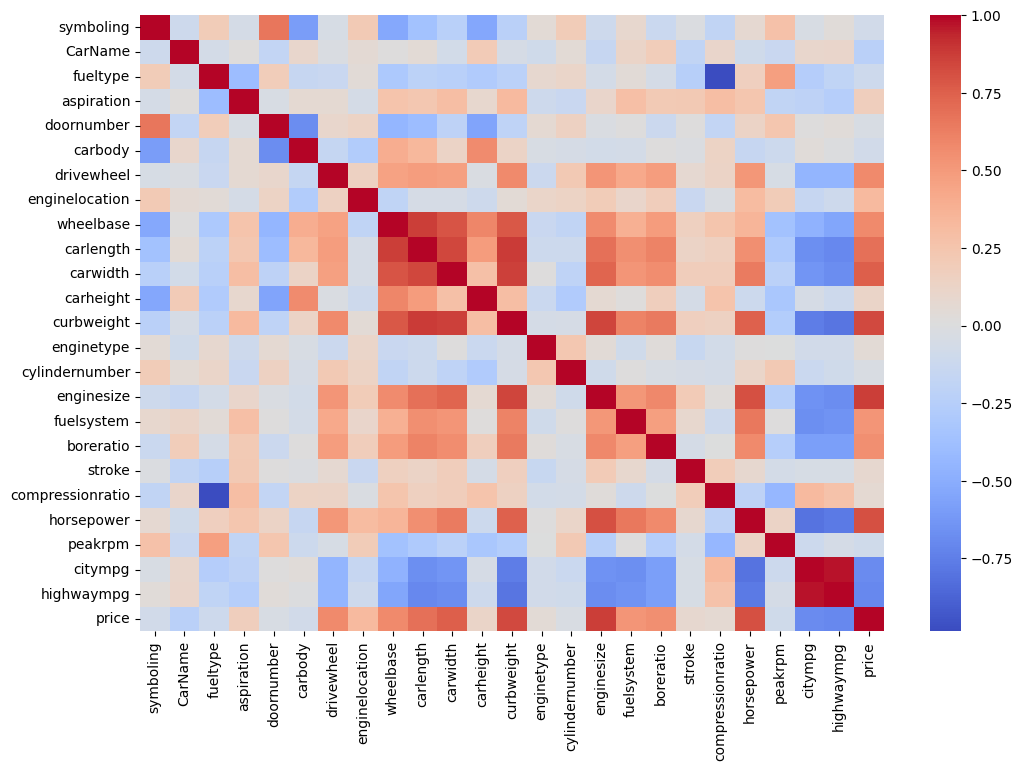

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()


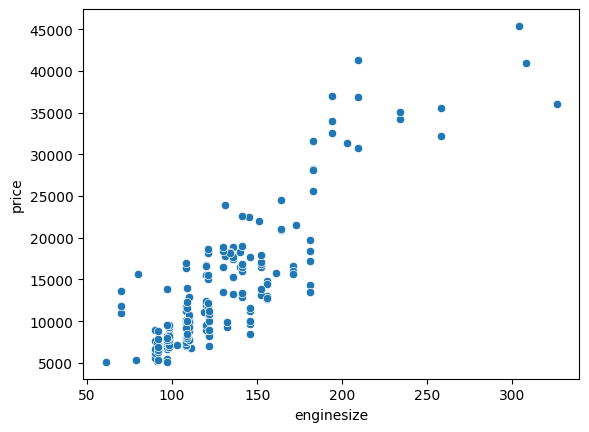

In [11]:
sns.scatterplot(x="enginesize", y="price", data=df)
plt.show()

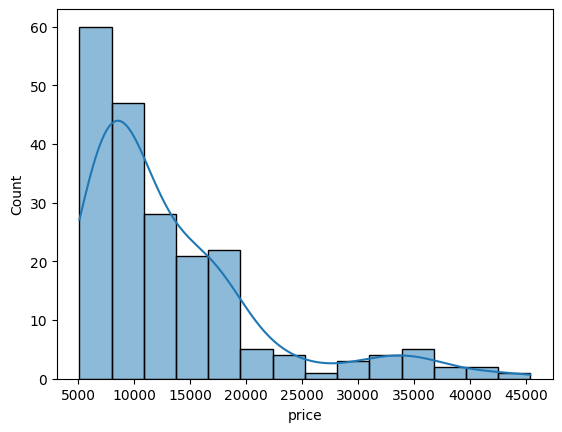

In [12]:
sns.histplot(df["price"], kde=True)
plt.show()

In [13]:
scaler = StandardScaler()

X = df.drop("price", axis=1)
y = df["price"]

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(x_test)

print(y_pred)

[25653.10322076 17598.74148462  9669.27654344 13535.57665124
 26527.85617514  6322.55589502  8498.34641517  5774.02823388
  9519.7586162   6903.1887775  13803.98729703  5950.7499891
 16679.67101398 10432.80769795 40132.97143166  6600.22005442
   -50.81104432 14365.95782137  9648.47563341 10453.46229641
 11102.56580569 21056.21805417  7948.16420041  3235.15701746
  7717.61022734 24445.86380165 14023.91307823 15818.12775588
  5249.28332054 16195.39806549 26548.75947711  7090.56452652
  4526.14782278 22076.94891349  8251.77885968 26788.87986187
 10066.02430772  9770.22115645  6831.1540548  14660.50118738
  7435.45461509]


In [17]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

R2 Score : 0.8407071151499271
MSE : 12575220.827585058


In [18]:
new_data = pd.DataFrame({
    "symboling":[1],
    "CarName":[0],
    "fueltype":[1],
    "aspiration":[0],
    "doornumber":[1],
    "carbody":[2],
    "drivewheel":[1],
    "enginelocation":[0],
    "wheelbase":[95.7],
    "carlength":[170.0],
    "carwidth":[65.5],
    "carheight":[52.4],
    "curbweight":[2300],
    "enginetype":[0],
    "cylindernumber":[2],
    "enginesize":[130],
    "fuelsystem":[1],
    "boreratio":[3.2],
    "stroke":[3.4],
    "compressionratio":[9.0],
    "horsepower":[110],
    "peakrpm":[5000],
    "citympg":[25],
    "highwaympg":[30]
})

new_data = pd.DataFrame(
    scaler.transform(new_data),
    columns=new_data.columns
)

prediction = model.predict(new_data)

print("Predicted Car Price:", prediction[0])

Predicted Car Price: 11864.299281296788


In [19]:
import joblib

joblib.dump(model, "car_price_model.joblib")

['car_price_model.joblib']